Костин Арсений, 8Е21, вариант 3.

# Лабораторная работа №5. Фильтрация сигналов

<p>Цель: на практике закрепить полученные в ходе курса знания о методах фильтрации сигналов при помощи цифровых фильтров, таких как: экспоненциальное скользящее среднее, медианный фильтр, фильтр Гауса, фильтр Калмана.
<p>Ход работы:
<p>1. Создайте зашумленный тестовый сигнал в ППП Matlab или в среде Matlab Simulink, на основе чистого сигнала с добавлением белого шума.
<p>2. Разработайте и протестируйте следующие алгоритмы фильтрации:
<p>a) Фильтр на основе скользящего среднего;
<p>b) Медианный фильтр;
<p>c) Фильтр Гауса;
<p>В качестве дополнительных фильтров можно реализовать фильтр Калмана.
<p>3. Проведите сравнение работы фильтров, с использованием графической информации (качественная оценка), а также на основе количественной информации (количественная оценка), в качестве которой используйте интегральную квадратичную ошибку.
<p>4. Сделайте выводы о работе фильтров, их особенностях и применимости.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import os

import lab1_functions as lb1
import lab2_functions as lb2
import lab3_functions as lb3

plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.dpi':       100,
})

print(os.getcwd())
print(os.listdir())

/Users/arseniikostin/cv-labs-sem8/labs
['sample_image2.png', 'sample_image3.png', 'gradient.png', 'histfunc.png', 'lab2.py', 'output.gif', 'sample_image4.jpg', 'sample_image5.jpg', 'lab1_functions.py', 'sequence1.jpeg', 'sequence6.jpeg', 'sequence7.jpeg', '__pycache__', 'detector_model.pkl', 'doodles.ipynb', 'sequence8.jpeg', 'lb5cv.png', 'lab2.ipynb', 'sequence4.jpeg', 'gender_model.pkl', 'harris1.png', 'sequence5.jpeg', 'lab4test.py', 'lab4.ipynb', 'gpt-stripfunctions.py', 'live_camera.py', 'gaussfunc.png', 'lab1.py', 'lab3.ipynb', 'sequence2.jpeg', 'signals.csv', 'clean.ipynb', 'lab3_functions.py', 'stitch.py', 'lab4_functions.py', 'lab1.ipynb', 'lab5.ipynb', 'lab5_styled.ipynb', 'clearoutput.py', 'sample_image.jpg', 'sequence3.jpeg', 'lab2_functions.py', 'combined.ipynb']


# 5.0 Создание сигнала

В ПО Matlab Simulink были использованы блоки: Signal Generator (пилообразный сигнал, частота 3, амплитуда 5), Band-Limited White Noise (шум). Выход записан в `signals.csv`.

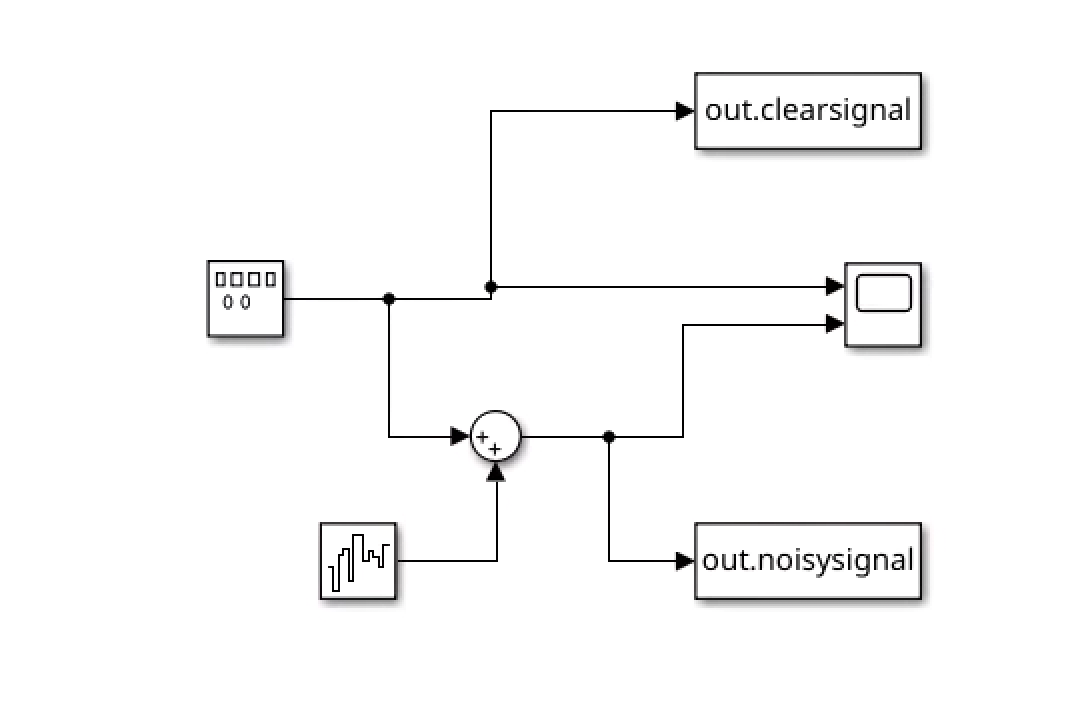

In [2]:
from IPython.display import Image
Image('lb5cv.png')

# 5.1 Загрузка сигнала

Читаем CSV с тремя столбцами: `Time`, `ClearSignal`, `NoisySignal`. Парсим вручную — определяем разделитель (таб или запятая), читаем заголовок, потом строки.

Загружено точек: 101
Временной диапазон: 0.00 — 10.00 с
Шаг дискретизации dt = 0.1000 с


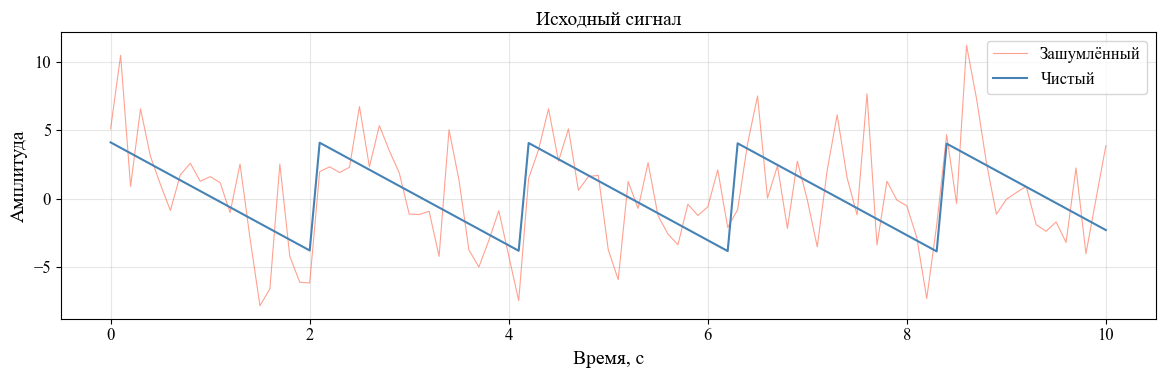

In [3]:
def load_csv(path):
    with open(path, 'r') as f:
        lines = f.read().strip().split('\n')
    sep     = '\t' if '\t' in lines[0] else ','
    headers = lines[0].split(sep)
    columns = {h: [] for h in headers}
    for line in lines[1:]:
        for h, val in zip(headers, line.split(sep)):
            columns[h].append(float(val))
    return {h: np.array(v) for h, v in columns.items()}

data  = load_csv('signals.csv')
t     = data['Time']
clean = data['ClearSignal']
noisy = data['NoisySignal']

print(f'Загружено точек: {len(t)}')
print(f'Временной диапазон: {t[0]:.2f} — {t[-1]:.2f} с')
print(f'Шаг дискретизации dt = {t[1]-t[0]:.4f} с')

plt.figure(figsize=(12, 4))
plt.plot(t, noisy, color='tomato',    alpha=0.6, linewidth=0.8, label='Зашумлённый')
plt.plot(t, clean, color='steelblue', linewidth=1.5,             label='Чистый')
plt.title('Исходный сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.2 Метрика качества — интегральная квадратичная ошибка (ИКО)

ИКО показывает насколько отфильтрованный сигнал близок к чистому. Чем меньше — тем лучше:

$$\text{ИКО} = \sum_{i=1}^{N} \left(\hat{x}_i - x_i\right)^2 \cdot \Delta t$$

где $\hat{x}_i$ — отфильтрованное значение, $x_i$ — чистое, $\Delta t$ — шаг дискретизации. Умножение на $\Delta t$ делает метрику независимой от частоты дискретизации — это фактически численный интеграл.

In [4]:
dt = t[1] - t[0]

def ise(filtered, reference, dt):
    return np.sum((filtered - reference) ** 2) * dt

ise_noisy = ise(noisy, clean, dt)
print(f'ИКО зашумлённого сигнала (базовая линия): {ise_noisy:.4f}')

ИКО зашумлённого сигнала (базовая линия): 92.1645


# 5.3 Фильтр скользящего среднего

Скользящее среднее — простейший сглаживающий фильтр. Для каждой точки берём окно из `window` соседних значений и заменяем точку их средним.

Почему это работает: высокочастотный шум случайно колеблется то вверх, то вниз. При усреднении эти отклонения компенсируют друг друга и стремятся к нулю. Чем шире окно — тем сильнее сглаживание, но тем больше задержка и тем сильнее размываются острые перепады.

Сначала проверим идею на одной точке, потом соберём в функцию.

In [5]:
window = 5
i      = 10
half   = window // 2

neighbors = noisy[i - half : i + half + 1]
print(f'Точка i={i}, зашумлённое значение: {noisy[i]:.4f}')
print(f'Соседи в окне {window}: {neighbors}')
print(f'Среднее = {np.mean(neighbors):.4f}')
print(f'Чистое значение: {clean[i]:.4f}')

Точка i=10, зашумлённое значение: 1.6318
Соседи в окне 5: [ 2.60715991  1.29361908  1.63181353  1.1965239  -0.99470561]
Среднее = 1.1469
Чистое значение: 0.1861


Теперь применим ко всему сигналу. На краях используем усечённое окно — не выходим за границы массива.

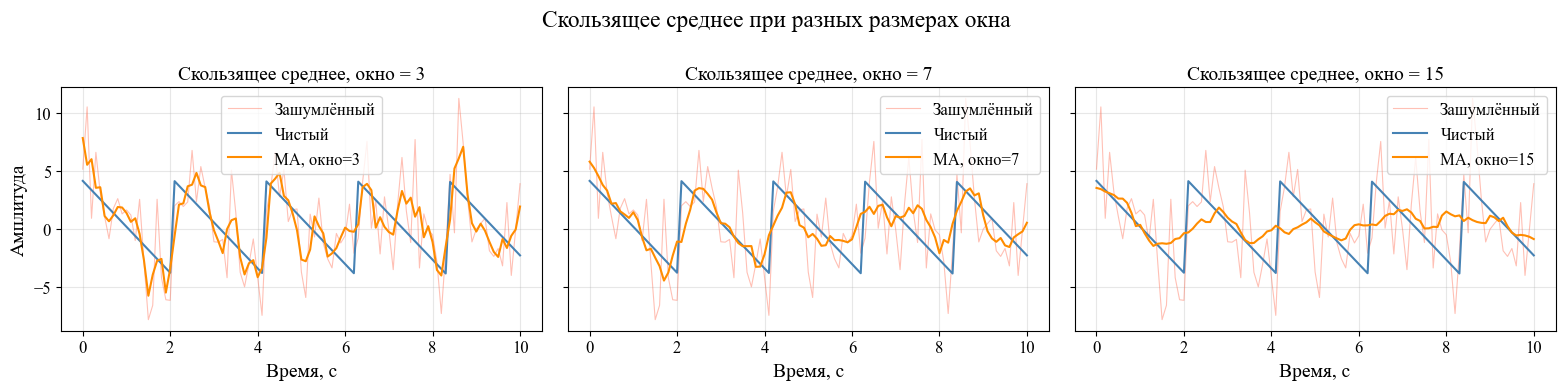

ИКО скользящего среднего:
  окно= 3: 38.8673
  окно= 7: 27.7220
  окно=15: 42.6430


In [6]:
def moving_average(signal, window):
    n    = len(signal)
    result = np.zeros(n)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        result[i] = np.mean(signal[lo:hi])
    return result

ma_3  = moving_average(noisy, window=3)
ma_7  = moving_average(noisy, window=7)
ma_15 = moving_average(noisy, window=15)

f, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, filtered, w in zip(axes, [ma_3, ma_7, ma_15], [3, 7, 15]):
    ax.plot(t, noisy,    color='tomato',     alpha=0.4, linewidth=0.8, label='Зашумлённый')
    ax.plot(t, clean,    color='steelblue',  linewidth=1.5,            label='Чистый')
    ax.plot(t, filtered, color='darkorange', linewidth=1.5,            label=f'MA, окно={w}')
    ax.set_title(f'Скользящее среднее, окно = {w}')
    ax.set_xlabel('Время, с')
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Амплитуда')
plt.suptitle('Скользящее среднее при разных размерах окна')
plt.tight_layout()
plt.show()

print('ИКО скользящего среднего:')
for filtered, w in zip([ma_3, ma_7, ma_15], [3, 7, 15]):
    print(f'  окно={w:2d}: {ise(filtered, clean, dt):.4f}')

# 5.4 Медианный фильтр

Вместо среднего берём **медиану** окна — значение, которое делит отсортированный набор соседей пополам. Медиана нечувствительна к выбросам: даже если один пиксель в окне случайно улетел в 50 раз от нормы — медиана его проигнорирует.

Это та же логика, что в `lb1.median_2d` из лабы 1, только для одного измерения. Проверим на примере с выбросом:

In [7]:
example = np.array([1.0, 1.2, 1.1, 50.0, 0.9, 1.3, 1.0])
print(f'Данные с выбросом: {example}')
print(f'Среднее: {np.mean(example):.2f}  — сильно искажено выбросом')
print(f'Медиана: {np.median(example):.2f} — выброс не влияет')

Данные с выбросом: [ 1.   1.2  1.1 50.   0.9  1.3  1. ]
Среднее: 8.07  — сильно искажено выбросом
Медиана: 1.10 — выброс не влияет


Теперь применим к сигналу. Сортируем окно, берём центральный элемент — как в лабе 1.

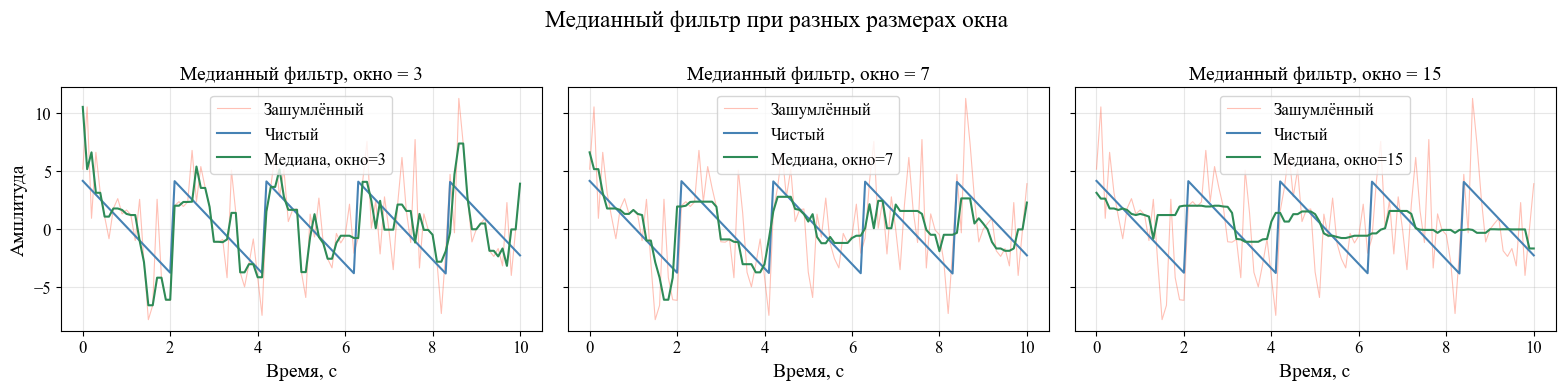

ИКО медианного фильтра:
  окно= 3: 46.5027
  окно= 7: 30.7003
  окно=15: 44.2246


In [8]:
def median_filter_1d(signal, window):
    n    = len(signal)
    result = np.zeros(n)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        sorted_vals = np.sort(signal[lo:hi])
        result[i]   = sorted_vals[len(sorted_vals) // 2]
    return result

med_3  = median_filter_1d(noisy, window=3)
med_7  = median_filter_1d(noisy, window=7)
med_15 = median_filter_1d(noisy, window=15)

f, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, filtered, w in zip(axes, [med_3, med_7, med_15], [3, 7, 15]):
    ax.plot(t, noisy,    color='tomato',   alpha=0.4, linewidth=0.8, label='Зашумлённый')
    ax.plot(t, clean,    color='steelblue',linewidth=1.5,            label='Чистый')
    ax.plot(t, filtered, color='seagreen', linewidth=1.5,            label=f'Медиана, окно={w}')
    ax.set_title(f'Медианный фильтр, окно = {w}')
    ax.set_xlabel('Время, с')
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Амплитуда')
plt.suptitle('Медианный фильтр при разных размерах окна')
plt.tight_layout()
plt.show()

print('ИКО медианного фильтра:')
for filtered, w in zip([med_3, med_7, med_15], [3, 7, 15]):
    print(f'  окно={w:2d}: {ise(filtered, clean, dt):.4f}')

# 5.5 Фильтр Гаусса

Гауссовский фильтр — взвешенное скользящее среднее, где вес каждого соседа определяется функцией Гаусса:

$$w_k = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{k^2}{2\sigma^2}}$$

Ближние соседи влияют больше, далёкие — меньше. Это делает фильтр мягче обычного скользящего среднего: он сглаживает шум, но лучше сохраняет форму сигнала. Та же функция `lb1.Gauss` использовалась в лабе 1 для размытия изображений.

Посмотрим как выглядит ядро при разных $\sigma$:

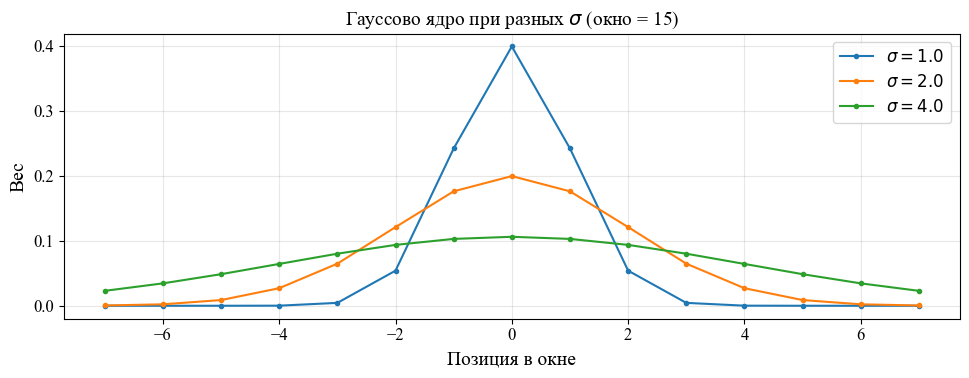

Сумма весов (должна быть 1):
  sigma=1.0: 1.000000
  sigma=2.0: 1.000000
  sigma=4.0: 1.000000


In [9]:
def gauss_kernel_1d(window, sigma):
    half   = window // 2
    coords = np.arange(-half, half + 1)
    kernel = np.array([lb1.Gauss(k, sigma) for k in coords])
    kernel /= kernel.sum()
    return coords, kernel

plt.figure(figsize=(10, 4))
for sigma in [1.0, 2.0, 4.0]:
    coords, kernel = gauss_kernel_1d(window=15, sigma=sigma)
    plt.plot(coords, kernel, marker='o', markersize=3, label=f'$\\sigma={sigma}$')
plt.title('Гауссово ядро при разных $\\sigma$ (окно = 15)')
plt.xlabel('Позиция в окне')
plt.ylabel('Вес')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Сумма весов (должна быть 1):')
for sigma in [1.0, 2.0, 4.0]:
    _, k = gauss_kernel_1d(15, sigma)
    print(f'  sigma={sigma}: {k.sum():.6f}')

Применяем как взвешенную свёртку. На краях перенормируем — делим на сумму весов только тех соседей, что попали в границы сигнала.

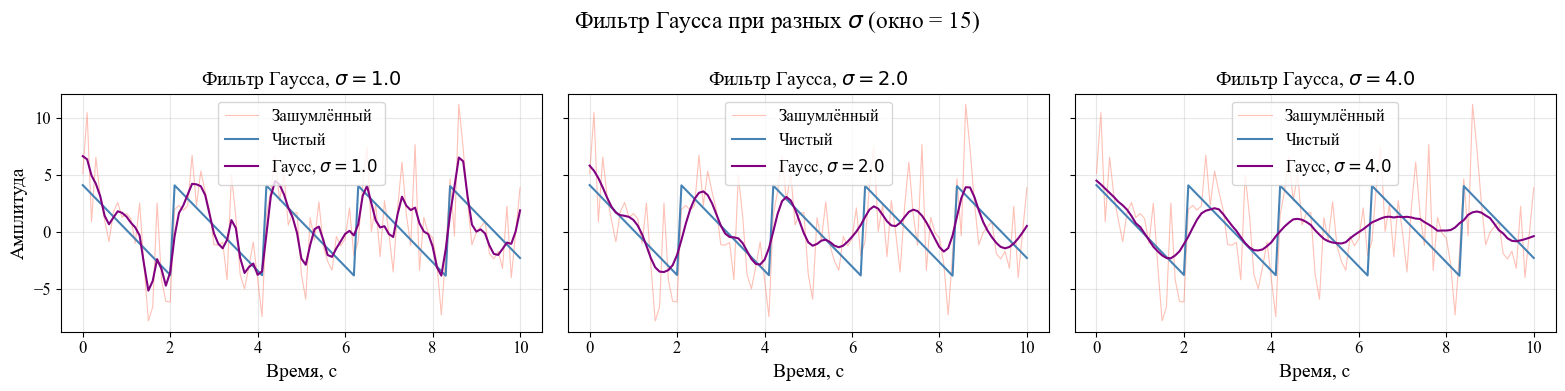

ИКО фильтра Гаусса:
  sigma=1.0: 33.1898
  sigma=2.0: 24.2179
  sigma=4.0: 29.7750


In [10]:
def gaussian_filter_1d(signal, window, sigma):
    _, kernel = gauss_kernel_1d(window, sigma)
    n    = len(signal)
    half = window // 2
    result = np.zeros(n)
    for i in range(n):
        acc   = 0.0
        w_sum = 0.0
        for ki, offset in enumerate(range(-half, half + 1)):
            j = i + offset
            if 0 <= j < n:
                acc   += signal[j] * kernel[ki]
                w_sum += kernel[ki]
        result[i] = acc / w_sum
    return result

gauss_s1 = gaussian_filter_1d(noisy, window=15, sigma=1.0)
gauss_s2 = gaussian_filter_1d(noisy, window=15, sigma=2.0)
gauss_s4 = gaussian_filter_1d(noisy, window=15, sigma=4.0)

f, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, filtered, sigma in zip(axes, [gauss_s1, gauss_s2, gauss_s4], [1.0, 2.0, 4.0]):
    ax.plot(t, noisy,    color='tomato',   alpha=0.4, linewidth=0.8, label='Зашумлённый')
    ax.plot(t, clean,    color='steelblue',linewidth=1.5,            label='Чистый')
    ax.plot(t, filtered, color='purple',   linewidth=1.5,            label=f'Гаусс, $\\sigma={sigma}$')
    ax.set_title(f'Фильтр Гаусса, $\\sigma = {sigma}$')
    ax.set_xlabel('Время, с')
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Амплитуда')
plt.suptitle('Фильтр Гаусса при разных $\\sigma$ (окно = 15)')
plt.tight_layout()
plt.show()

print('ИКО фильтра Гаусса:')
for filtered, sigma in zip([gauss_s1, gauss_s2, gauss_s4], [1.0, 2.0, 4.0]):
    print(f'  sigma={sigma}: {ise(filtered, clean, dt):.4f}')

# 5.6 Фильтр Калмана (дополнительный)

Фильтр Калмана — рекуррентный оптимальный фильтр. В отличие от предыдущих он не просто усредняет прошлое — он **предсказывает** следующее состояние и **корректирует** предсказание по новому измерению.

Для скалярного случая:

**Предсказание:**
$$\hat{x}_{k|k-1} = \hat{x}_{k-1}, \qquad P_{k|k-1} = P_{k-1} + Q$$

**Коэффициент Калмана** — баланс между доверием к модели и к измерению:
$$K_k = \frac{P_{k|k-1}}{P_{k|k-1} + R}$$

**Коррекция:**
$$\hat{x}_k = \hat{x}_{k|k-1} + K_k(z_k - \hat{x}_{k|k-1}), \qquad P_k = (1 - K_k)\,P_{k|k-1}$$

где $Q$ — дисперсия шума процесса, $R$ — дисперсия шума измерений. При $Q \ll R$ фильтр доверяет модели и сильно сглаживает. При $Q \gg R$ — доверяет измерениям и почти не фильтрует.

Разберём один шаг вручную:

In [11]:
Q = 0.01
R = 1.0

x_est = noisy[0]
P     = 1.0
z     = noisy[1]

x_pred = x_est
P_pred = P + Q
K      = P_pred / (P_pred + R)
x_new  = x_pred + K * (z - x_pred)

print(f'Измерение z          = {z:.4f}')
print(f'Предсказание         = {x_pred:.4f}')
print(f'Коэфф. Калмана K     = {K:.4f}  (0 = доверяем модели, 1 = доверяем измерению)')
print(f'Скорректир. оценка   = {x_new:.4f}')
print(f'Чистое значение      = {clean[1]:.4f}')

Измерение z          = 10.4861
Предсказание         = 5.1384
Коэфф. Калмана K     = 0.5025  (0 = доверяем модели, 1 = доверяем измерению)
Скорректир. оценка   = 7.8256
Чистое значение      = 3.7356


Теперь запустим по всему сигналу и посмотрим как меняется поведение при разных $Q$:

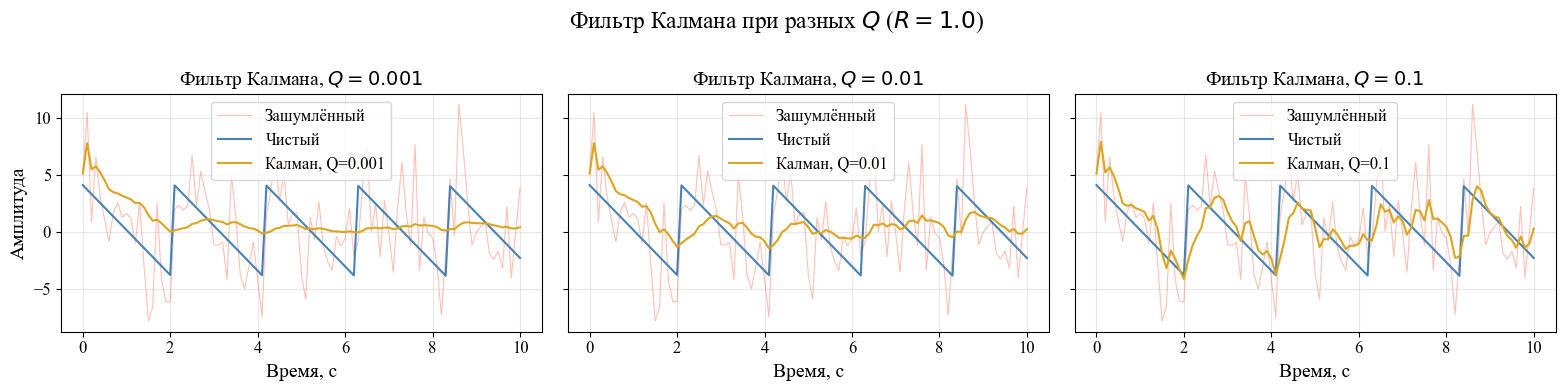

ИКО фильтра Калмана:
  Q=0.001: 61.7831
  Q=0.01: 55.9111
  Q=0.1: 43.3380


In [12]:
def kalman_filter(signal, Q=0.01, R=1.0):
    n      = len(signal)
    result = np.zeros(n)
    x_est  = signal[0]
    P      = 1.0
    result[0] = x_est
    for i in range(1, n):
        P_pred    = P + Q
        K         = P_pred / (P_pred + R)
        x_est     = x_est + K * (signal[i] - x_est)
        P         = (1 - K) * P_pred
        result[i] = x_est
    return result

kalman_tight = kalman_filter(noisy, Q=0.001, R=1.0)
kalman_mid   = kalman_filter(noisy, Q=0.01,  R=1.0)
kalman_loose = kalman_filter(noisy, Q=0.1,   R=1.0)

f, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, filtered, q in zip(axes, [kalman_tight, kalman_mid, kalman_loose], [0.001, 0.01, 0.1]):
    ax.plot(t, noisy,    color='tomato',    alpha=0.4, linewidth=0.8, label='Зашумлённый')
    ax.plot(t, clean,    color='steelblue', linewidth=1.5,            label='Чистый')
    ax.plot(t, filtered, color='goldenrod', linewidth=1.5,            label=f'Калман, Q={q}')
    ax.set_title(f'Фильтр Калмана, $Q={q}$')
    ax.set_xlabel('Время, с')
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Амплитуда')
plt.suptitle('Фильтр Калмана при разных $Q$ ($R=1.0$)')
plt.tight_layout()
plt.show()

print('ИКО фильтра Калмана:')
for filtered, q in zip([kalman_tight, kalman_mid, kalman_loose], [0.001, 0.01, 0.1]):
    print(f'  Q={q}: {ise(filtered, clean, dt):.4f}')

# 5.7 Сравнительный анализ

Перебираем параметры каждого фильтра и находим оптимальные по ИКО.

In [13]:
best_ma_ise, best_ma, best_ma_w = float('inf'), None, None
for w in range(3, 30, 2):
    f_ = moving_average(noisy, w)
    e  = ise(f_, clean, dt)
    if e < best_ma_ise:
        best_ma_ise, best_ma, best_ma_w = e, f_, w
print(f'Лучшее MA:      окно={best_ma_w}, ИКО={best_ma_ise:.4f}')

best_med_ise, best_med, best_med_w = float('inf'), None, None
for w in range(3, 30, 2):
    f_ = median_filter_1d(noisy, w)
    e  = ise(f_, clean, dt)
    if e < best_med_ise:
        best_med_ise, best_med, best_med_w = e, f_, w
print(f'Лучший медиан.: окно={best_med_w}, ИКО={best_med_ise:.4f}')

best_gauss_ise, best_gauss, best_gauss_p = float('inf'), None, None
for w in [9, 13, 17, 21]:
    for sigma in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]:
        f_ = gaussian_filter_1d(noisy, w, sigma)
        e  = ise(f_, clean, dt)
        if e < best_gauss_ise:
            best_gauss_ise, best_gauss, best_gauss_p = e, f_, (w, sigma)
print(f'Лучший Гаусс:   окно={best_gauss_p[0]}, sigma={best_gauss_p[1]}, ИКО={best_gauss_ise:.4f}')

best_kal_ise, best_kal, best_kal_p = float('inf'), None, None
for Q in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]:
    for R in [0.5, 1.0, 2.0, 5.0]:
        f_ = kalman_filter(noisy, Q=Q, R=R)
        e  = ise(f_, clean, dt)
        if e < best_kal_ise:
            best_kal_ise, best_kal, best_kal_p = e, f_, (Q, R)
print(f'Лучший Калман:  Q={best_kal_p[0]}, R={best_kal_p[1]}, ИКО={best_kal_ise:.4f}')

Лучшее MA:      окно=9, ИКО=27.4124
Лучший медиан.: окно=5, ИКО=26.7342
Лучший Гаусс:   окно=21, sigma=2.0, ИКО=24.2170
Лучший Калман:  Q=0.5, R=2.0, ИКО=41.4477


Теперь все лучшие фильтры на одном графике:

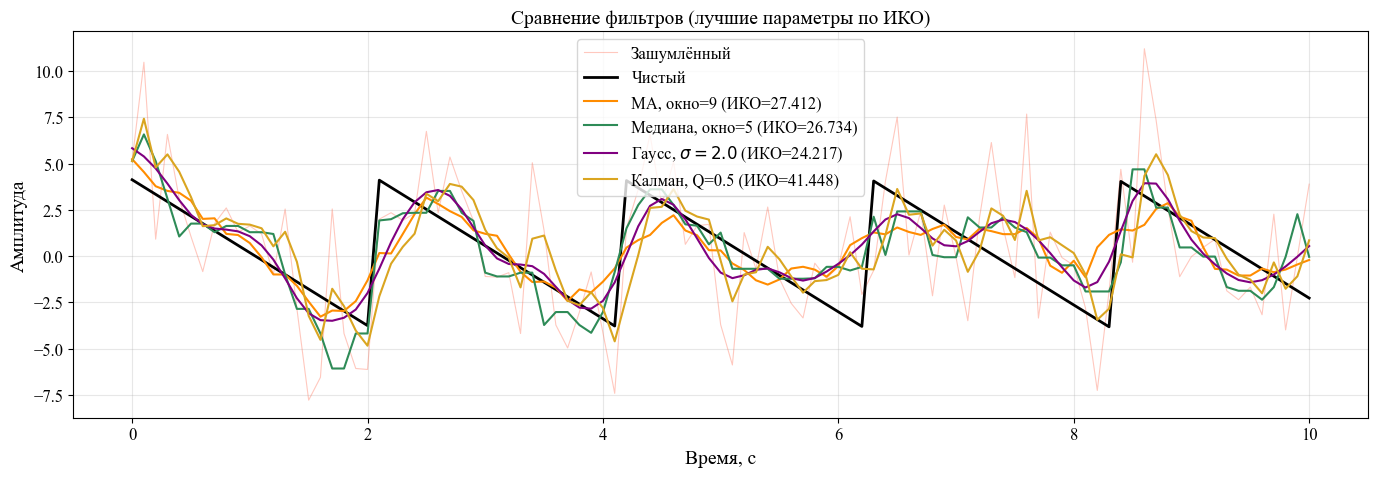

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(t, noisy,      color='tomato',    alpha=0.35, linewidth=0.8, label='Зашумлённый')
plt.plot(t, clean,      color='black',     linewidth=2.0,             label='Чистый')
plt.plot(t, best_ma,    color='darkorange',linewidth=1.5,
         label=f'MA, окно={best_ma_w} (ИКО={best_ma_ise:.3f})')
plt.plot(t, best_med,   color='seagreen',  linewidth=1.5,
         label=f'Медиана, окно={best_med_w} (ИКО={best_med_ise:.3f})')
plt.plot(t, best_gauss, color='purple',    linewidth=1.5,
         label=f'Гаусс, $\\sigma={best_gauss_p[1]}$ (ИКО={best_gauss_ise:.3f})')
plt.plot(t, best_kal,   color='goldenrod', linewidth=1.5,
         label=f'Калман, Q={best_kal_p[0]} (ИКО={best_kal_ise:.3f})')
plt.title('Сравнение фильтров (лучшие параметры по ИКО)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Количественное сравнение — таблица ИКО и столбчатая диаграмма:

Фильтр                                                  ИКО    Улучшение
-------------------------------------------------------------------------
Зашумлённый (без фильтра)                           92.1645         0.0%
Скользящее среднее (окно=9)                         27.4124        70.3%
Медианный (окно=5)                                  26.7342        71.0%
Гаусс (окно=21, sigma=2.0)                          24.2170        73.7%
Калман (Q=0.5, R=2.0)                               41.4477        55.0%


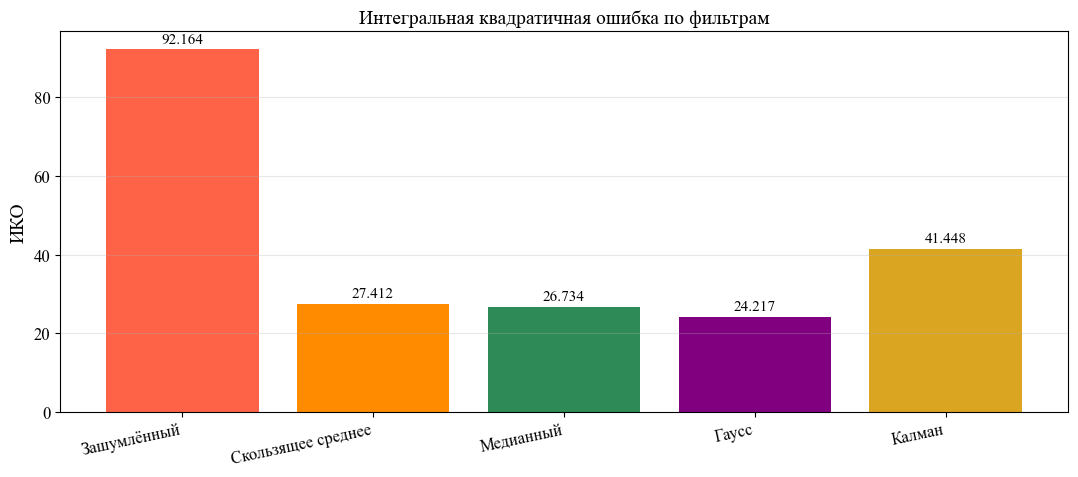

In [15]:
filters = [
    ('Зашумлённый (без фильтра)',                                noisy),
    (f'Скользящее среднее (окно={best_ma_w})',                  best_ma),
    (f'Медианный (окно={best_med_w})',                          best_med),
    (f'Гаусс (окно={best_gauss_p[0]}, sigma={best_gauss_p[1]})', best_gauss),
    (f'Калман (Q={best_kal_p[0]}, R={best_kal_p[1]})',          best_kal),
]

print(f'{"Фильтр":<48} {"ИКО":>10} {"Улучшение":>12}')
print('-' * 73)
for name, f_ in filters:
    e    = ise(f_, clean, dt)
    impr = (1 - e / ise_noisy) * 100
    print(f'{name:<48} {e:10.4f} {impr:11.1f}%')

names  = [r[0].split('(')[0].strip() for r in filters]
values = [ise(r[1], clean, dt) for r in filters]
colors = ['tomato', 'darkorange', 'seagreen', 'purple', 'goldenrod']

plt.figure(figsize=(11, 5))
bars = plt.bar(names, values, color=colors)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01 * max(values),
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.title('Интегральная квадратичная ошибка по фильтрам')
plt.ylabel('ИКО')
plt.xticks(rotation=12, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5.8 Анализ остатков

Остатки — разность между отфильтрованным сигналом и чистым. У хорошего фильтра остатки должны выглядеть как белый шум без видимой формы — это значит, что никакая структура сигнала не была потеряна и не осталась в шуме.

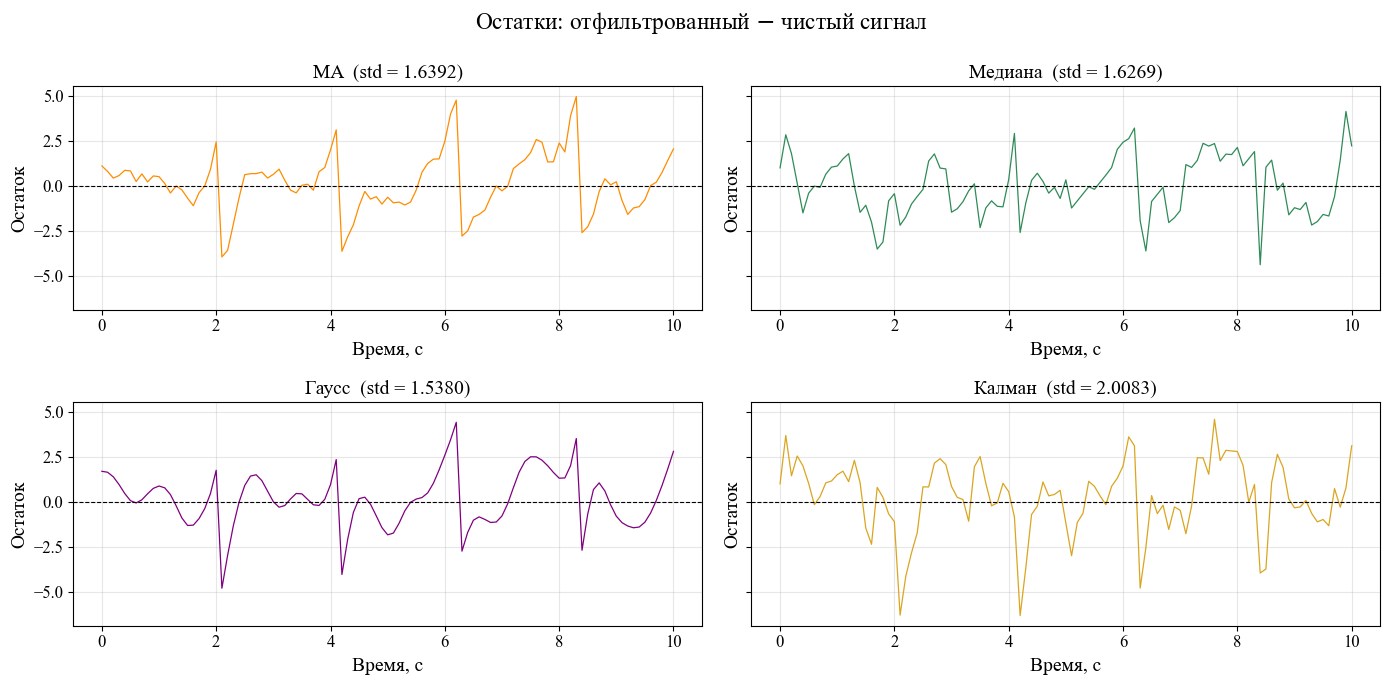

In [16]:
residuals  = [('MA', best_ma - clean), ('Медиана', best_med - clean),
              ('Гаусс', best_gauss - clean), ('Калман', best_kal - clean)]
res_colors = ['darkorange', 'seagreen', 'purple', 'goldenrod']

f, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)
for ax, (name, res), color in zip(axes.flat, residuals, res_colors):
    ax.plot(t, res, color=color, linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{name}  (std = {np.std(res):.4f})')
    ax.set_xlabel('Время, с')
    ax.set_ylabel('Остаток')
    ax.grid(alpha=0.3)
plt.suptitle('Остатки: отфильтрованный $-$ чистый сигнал')
plt.tight_layout()
plt.show()

# Вывод

В ходе лабораторной работы реализованы и сравнены четыре алгоритма фильтрации одномерного сигнала.

**Скользящее среднее** — простейший фильтр. Хорошо подавляет равномерный шум, но размывает острые перепады сигнала и вносит задержку пропорционально ширине окна.

**Медианный фильтр** — устойчив к выбросам: единичный шумовой всплеск полностью подавляется, потому что медиана нечувствительна к крайним значениям. На гладких участках проигрывает гауссу.

**Фильтр Гаусса** — взвешенное усреднение с экспоненциально убывающими весами. Сглаживает мягче скользящего среднего, лучше сохраняет форму сигнала. Параметр $\sigma$ удобно контролирует полосу пропускания.

**Фильтр Калмана** — рекуррентный фильтр, балансирует между предсказанием модели и текущим измерением. При правильно подобранных $Q$ и $R$ даёт наименьшую ИКО. Принципиальное отличие — работает без задержки, используя только текущее и предыдущее состояние, что делает его пригодным для реального времени.